# Movie split, user EDA and train-only aggregates

Split the data for the rating model and look at the users before clustering them.

- **Split by movie** (70% train / 15% validation / 15% test). The project targets *cold start*: predicting ratings for a movie nobody has rated yet, from its TMDB metadata. Validation and test movies are therefore never seen in training; all users can appear in all three parts.
- **User EDA** on training-movie ratings: how many ratings users have, how much of a rating is explained by the user vs. the movie and whether users differ in genre taste.
- **Train-only aggregates** for the next notebooks: movie rating statistics, director / cast track records and user statistics, all computed from **training movies only** so nothing leaks from validation / test movies.

## 1. Load

Movie features come from `05_movie_features.ipynb`. Ratings (~57M rows) are read in chunks with compact integer types to keep memory low; the `date` column is not needed.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

PROCESSED = Path("../data/processed")
RANDOM_STATE = 42

movies = pd.read_csv(PROCESSED / "movies_features.csv", converters={"cast_top5": json.loads})
GENRE_COLS = [c for c in movies.columns if c.startswith("genre_")]

chunks = pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=["netflix_movie_id", "rater_id", "rating"],
    dtype={"netflix_movie_id": "int32", "rater_id": "int32", "rating": "int8"},
    chunksize=5_000_000,
)
ratings = pd.concat(chunks, ignore_index=True)
n_all = len(ratings)
ratings = ratings[ratings["netflix_movie_id"].isin(movies["netflix_movie_id"])].reset_index(drop=True)

print(f"movies: {movies.shape}")
print(f"ratings: {len(ratings):,} (dropped {n_all - len(ratings):,} of movies without features)")
print(f"raters: {ratings['rater_id'].nunique():,}")

movies: (1314, 48)
ratings: 51,475,729 (dropped 5,710,837 of movies without features)
raters: 463,656


## 2. Movie split

Movies are split 70 / 15 / 15, **stratified** so that the three parts look alike:
- popularity (tercile of the number of ratings) × era (before 1980, 1980s, 1990s, 2000s): popular recent blockbusters and rarely rated old films should appear in every part;
- documentaries form their own stratum (only 10 movies), so some of them are in training and documentary taste can enter the persona profiles.

The number of ratings is used only to stratify, not as a feature.

In [2]:
movie_n = ratings.groupby("netflix_movie_id").size().rename("n_ratings")
movie_mean = ratings.groupby("netflix_movie_id")["rating"].mean().rename("avg_rating")
movies = movies.join(movie_n, on="netflix_movie_id").join(movie_mean, on="netflix_movie_id")

era = pd.cut(movies["year"], [0, 1979, 1989, 1999, 2005], labels=["<1980", "1980s", "1990s", "2000s"])
popularity = pd.qcut(movies["n_ratings"], 3, labels=["low", "mid", "high"])
strata = np.where(movies["genre_documentary"] == 1, "documentary", popularity.astype(str) + "_" + era.astype(str))
print("smallest strata:", pd.Series(strata).value_counts().tail(4).to_dict())

ids = movies["netflix_movie_id"].to_numpy()
train_ids, rest_ids, _, rest_strata = train_test_split(
    ids, strata, test_size=0.30, stratify=strata, random_state=RANDOM_STATE
)
val_ids, test_ids = train_test_split(
    rest_ids, test_size=0.50, stratify=rest_strata, random_state=RANDOM_STATE
)

split_of = {**{m: "train" for m in train_ids}, **{m: "val" for m in val_ids}, **{m: "test" for m in test_ids}}
movies["split"] = movies["netflix_movie_id"].map(split_of)
assert movies["split"].notna().all()
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
movies["split"].value_counts()

smallest strata: {'mid_<1980': 46, 'high_1980s': 36, 'high_<1980': 22, 'documentary': 10}


split
train    919
test     198
val      197
Name: count, dtype: int64

**Balance check.** The three parts should have similar ratings, popularity, age and genre mix. (`avg_rating` of validation / test movies is used here only as a check, never as a feature.)

In [3]:
balance = movies.groupby("split").agg(
    movies=("netflix_movie_id", "size"),
    ratings=("n_ratings", "sum"),
    median_n_ratings=("n_ratings", "median"),
    avg_rating=("avg_rating", "mean"),
    year=("year", "mean"),
    runtime=("runtime", "mean"),
    log_roi=("log_roi", "mean"),
    drama=("genre_drama", "mean"),
    comedy=("genre_comedy", "mean"),
    horror=("genre_horror", "mean"),
    documentaries=("genre_documentary", "sum"),
    us_only=("us_only", "mean"),
).loc[["train", "val", "test"]]
balance["pct_ratings"] = 100 * balance["ratings"] / balance["ratings"].sum()
balance.round(2)

,movies,ratings,median_n_ratings,avg_rating,year,runtime,log_roi,drama,comedy,horror,documentaries,us_only,pct_ratings
split,,,,,,,,,,,,,
train,919,35696836,25098.0,3.44,1993.77,112.28,0.81,0.44,0.38,0.10,7,0.72,69.35
val,197,8124539,22845.0,3.46,1993.94,114.75,0.82,0.49,0.30,0.11,2,0.72,15.78
test,198,7654354,25796.5,3.46,1994.22,113.20,0.92,0.48,0.34,0.07,1,0.72,14.87


Every rating gets the split of its movie. A lookup array indexed by movie id is used instead of `map` so the 57M-row column stays one byte per row.

In [4]:
SPLITS = np.array(["train", "val", "test"])
split_lut = np.full(ratings["netflix_movie_id"].max() + 1, -1, dtype="int8")
for code_, name in enumerate(SPLITS):
    split_lut[movies.loc[movies["split"] == name, "netflix_movie_id"].to_numpy()] = code_
ratings["split"] = split_lut[ratings["netflix_movie_id"].to_numpy()]
assert (ratings["split"] >= 0).all()

train_ratings = ratings[ratings["split"] == 0]
print({name: f"{int((ratings['split'] == i).sum()):,}" for i, name in enumerate(SPLITS)})

movies[["netflix_movie_id", "split"]].to_csv(PROCESSED / "movie_split.csv", index=False)

{np.str_('train'): '35,696,836', np.str_('val'): '8,124,539', np.str_('test'): '7,654,354'}


## 3. Ratings per user on training movies

A user's profile and persona are built from their ratings of **training movies** only, so a minimum number of such ratings is needed for a stable profile. The table shows, for each threshold, how many users qualify and what share of the validation / test ratings belongs to them (the ratings the model can be evaluated on).

,users,pct_users,pct_val_test_ratings
min_train_ratings,,,
5,451358,97.3,99.8
10,411621,88.8,98.9
20,332632,71.7,95.6
30,274007,59.1,91.6
50,207391,44.7,84.3
100,120415,26.0,66.6


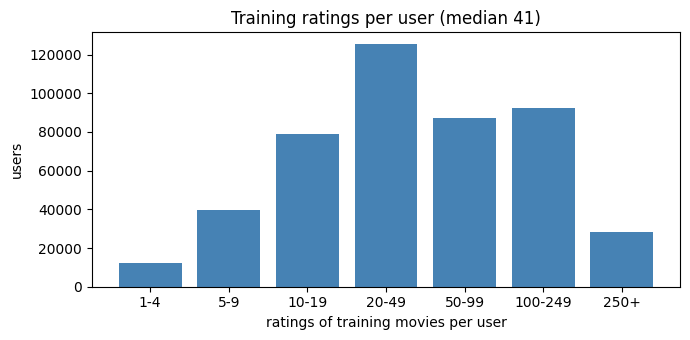

In [5]:
train_n = train_ratings.groupby("rater_id").size()
eval_n = ratings[ratings["split"] > 0].groupby("rater_id").size()
n_users = ratings["rater_id"].nunique()

rows = []
for min_n in [5, 10, 20, 30, 50, 100]:
    kept = train_n.index[train_n >= min_n]
    rows.append({
        "min_train_ratings": min_n,
        "users": len(kept),
        "pct_users": 100 * len(kept) / n_users,
        "pct_val_test_ratings": 100 * eval_n.reindex(kept).sum() / eval_n.sum(),
    })
display(pd.DataFrame(rows).set_index("min_train_ratings").round(1))

bins = [0, 4, 9, 19, 49, 99, 249, np.inf]
labels = ["1-4", "5-9", "10-19", "20-49", "50-99", "100-249", "250+"]
counts = pd.cut(train_n, bins=bins, labels=labels).value_counts().reindex(labels)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(labels, counts.values, color="steelblue")
ax.set_xlabel("ratings of training movies per user")
ax.set_ylabel("users")
ax.set_title(f"Training ratings per user (median {train_n.median():.0f})")
fig.tight_layout()
plt.show()

`MIN_TRAIN_RATINGS=20` is the threshold used from here on (user statistics, clustering, model).
It keeps 72% of users but 96% of the validation / test ratings. A user's taste profile is an average over their ratings, so 20 ratings also keep it from being mostly noise.

In [6]:
MIN_TRAIN_RATINGS = 20

eligible_users = train_n.index[train_n >= MIN_TRAIN_RATINGS]
print(f"eligible users: {len(eligible_users):,} of {n_users:,}")

eligible users: 332,632 of 463,656


## 4. User vs. movie: how much of a rating does each explain?

If users differ strongly in how generous they are, the user's mean rating is a key model feature. To measure this, each rating is "predicted" by a simple rule, and the rule is scored with **R²**:

$$R^2 = 1 - \frac{\sum (\text{rating} - \text{prediction})^2}{\sum (\text{rating} - \text{average rating})^2}$$

- The denominator is the total variation of the ratings: the squared error of the dumbest prediction, "every rating equals the overall average".
- The numerator is the squared error left after using the rule.
- So R² is the **share of the rating variation the rule explains**: 0 = no better than the overall average, 1 = every rating predicted exactly. For example, R² = 0.16 means the rule removes 16% of the squared error.

The three rules:
- **movie mean**: every rating is predicted by the movie's average rating (how good the movie is),
- **user mean**: every rating is predicted by the user's average rating (how generous the user is),
- **user + movie bias**: the movie's average plus the user's average offset from the movies they rated (how good the movie is, adjusted for how generous the user is; the classic recommender baseline).

Computed on training ratings of a random sample of 50,000 eligible users (to keep memory low); every rating of a sampled user is used.

In [7]:
N_SAMPLE_USERS = 50_000

rng = np.random.default_rng(RANDOM_STATE)
sample_users = rng.choice(eligible_users.to_numpy(), size=min(N_SAMPLE_USERS, len(eligible_users)), replace=False)
sample = train_ratings[train_ratings["rater_id"].isin(sample_users)].copy()
sample["rating"] = sample["rating"].astype(float)

global_mean = train_ratings["rating"].mean()
train_movie_mean = train_ratings.groupby("netflix_movie_id")["rating"].mean()

sample["movie_mean"] = sample["netflix_movie_id"].map(train_movie_mean)
sample["user_mean"] = sample.groupby("rater_id")["rating"].transform("mean")
user_offset = (sample["rating"] - sample["movie_mean"]).groupby(sample["rater_id"]).transform("mean")
sample["user_movie_bias"] = sample["movie_mean"] + user_offset

total_var = ((sample["rating"] - sample["rating"].mean()) ** 2).mean()
r2 = {
    name: 1 - ((sample["rating"] - sample[col]) ** 2).mean() / total_var
    for name, col in [("movie mean", "movie_mean"), ("user mean", "user_mean"), ("user + movie bias", "user_movie_bias")]
}
print(f"sample: {len(sample_users):,} users, {len(sample):,} ratings")
pd.Series(r2, name="R²").round(3)

sample: 50,000 users, 5,131,692 ratings


movie mean           0.102
user mean            0.157
user + movie bias    0.261
Name: R², dtype: float64

## 5. Do users differ in genre taste?

Persona clustering only makes sense if users differ in *which* genres they like, not only in how generous they are.

**Genre score** of a user (user–genre pairs with ≥ 5 ratings):

$$\text{genre score} = \text{user's average rating of the genre} - \text{user's overall average rating}$$

It is centred at 0 and is not affected by generosity. For example, a user with an overall average of 3.5 and an action average of 4.0 has an action score of **+0.5**.

**Comparison with luck.** Genre scores vary between users partly by chance (which films each user rated, rating noise). To measure that chance part, each user's ratings are **shuffled across their own movies**, which removes any real taste. The **spread ratio** compares the standard deviations:

$$\text{spread ratio} = \frac{\text{spread of real genre scores}}{\text{spread of shuffled genre scores}}$$

A ratio of 1 means users disagree about the genre no more than luck would produce; 1.38 (action) means 38% more spread than luck.

- **Plot 1:** histograms of genre scores for the 3 genres with the highest ratio (top) and the 3 lowest (bottom). Real users are blue and shuffled users grey. A blue histogram **wider** than the grey one means users disagree about the genre. One **shifted right** (documentary, war) means almost everyone rates the genre above their own average.
- **Plot 2:** the spread ratio of all 18 genres.

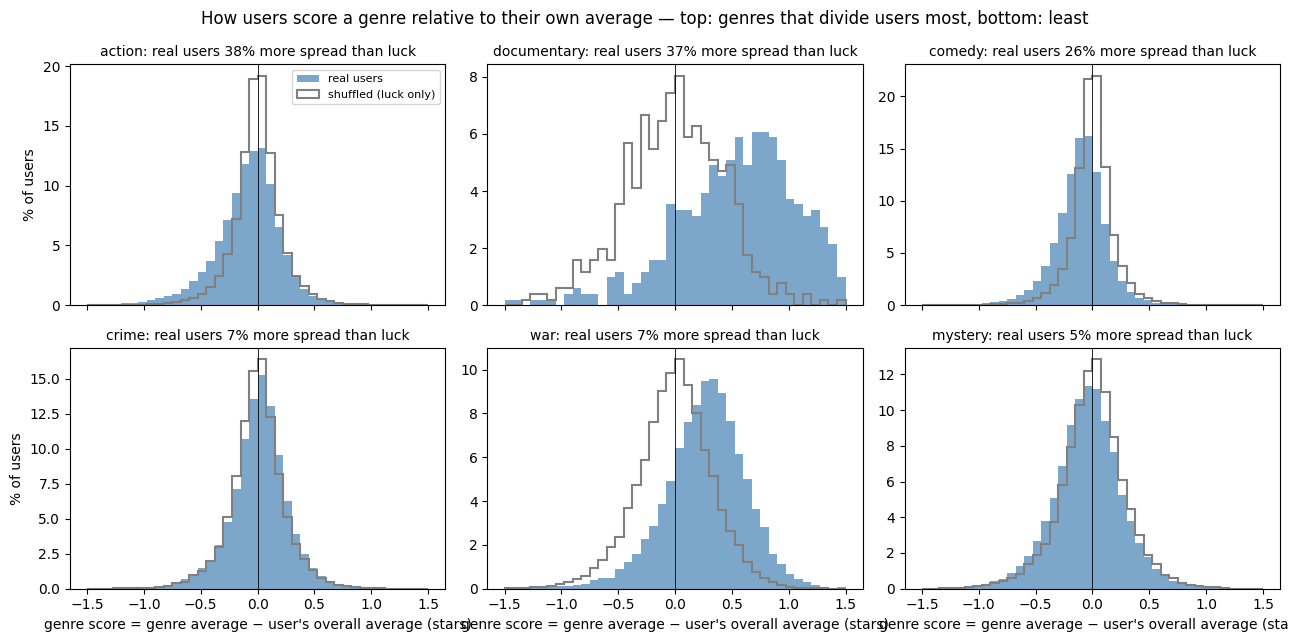

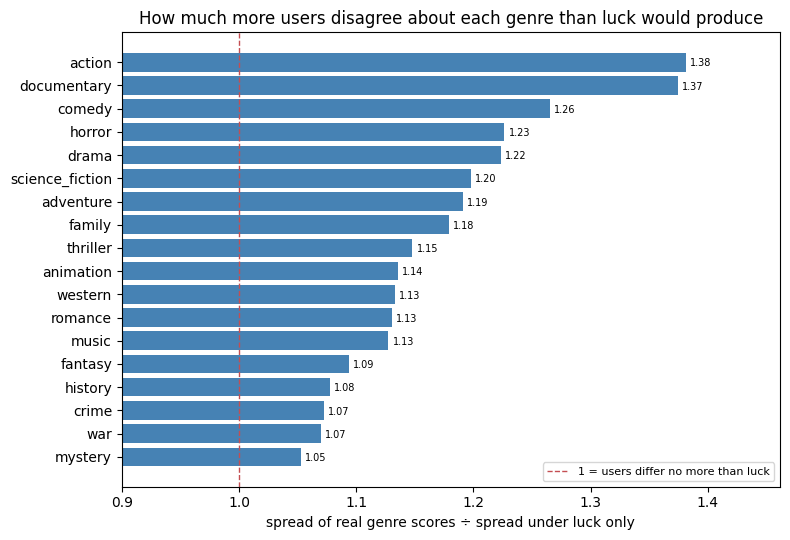

In [8]:
MIN_GENRE_RATINGS = 5

sample["dev"] = sample["rating"] - sample["user_mean"]
# permute deviations within each user: sort by user, then shuffle inside each user's block
sample = sample.sort_values("rater_id")
block_start = np.r_[0, np.flatnonzero(np.diff(sample["rater_id"].to_numpy())) + 1, len(sample)]
dev = sample["dev"].to_numpy()
dev_shuffled = np.concatenate([rng.permutation(dev[a:b]) for a, b in zip(block_start[:-1], block_start[1:])])
sample["dev_shuffled"] = dev_shuffled

genre_matrix = movies.set_index("netflix_movie_id")[GENRE_COLS]
g = genre_matrix.reindex(sample["netflix_movie_id"]).to_numpy()
rows, genre_scores = [], {}
for j, genre in enumerate(GENRE_COLS):
    in_genre = g[:, j] == 1
    part = sample.loc[in_genre, ["rater_id", "dev", "dev_shuffled"]]
    per_user = part.groupby("rater_id").agg(n=("dev", "size"), real=("dev", "mean"), shuffled=("dev_shuffled", "mean"))
    per_user = per_user[per_user["n"] >= MIN_GENRE_RATINGS]
    genre_scores[genre.removeprefix("genre_")] = per_user
    rows.append({
        "genre": genre.removeprefix("genre_"),
        "users": len(per_user),
        "mean_dev": per_user["real"].mean(),
        "spread_real": per_user["real"].std(),
        "spread_shuffled": per_user["shuffled"].std(),
    })
taste = pd.DataFrame(rows).set_index("genre")
taste["ratio"] = taste["spread_real"] / taste["spread_shuffled"]
taste = taste.sort_values("ratio", ascending=False)

# the 3 genres that divide users most and the 3 that divide them least
examples = list(taste.index[:3]) + list(taste.index[-3:])
bins = np.linspace(-1.5, 1.5, 41)
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for ax, genre in zip(axes.ravel(), examples):
    scores = genre_scores[genre]
    pct = np.full(len(scores), 100 / len(scores))  # each user counts as a share of all users -> y-axis in %
    ax.hist(scores["real"], bins=bins, weights=pct, color="steelblue", alpha=0.7, label="real users")
    ax.hist(scores["shuffled"], bins=bins, weights=pct, histtype="step", color="gray", lw=1.5, label="shuffled (luck only)")
    ax.axvline(0, color="black", lw=0.6)
    wider = 100 * (taste.loc[genre, "ratio"] - 1)
    ax.set_title(f"{genre}: real users {wider:.0f}% more spread than luck", fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel("% of users")
for ax in axes[1]:
    ax.set_xlabel("genre score = genre average − user's overall average (stars)")
axes[0, 0].legend(fontsize=8)
fig.suptitle("How users score a genre relative to their own average — top: genres that divide users most, bottom: least")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(taste.index[::-1], taste["ratio"][::-1], color="steelblue")
for y, v in enumerate(taste["ratio"][::-1]):
    ax.annotate(f"{v:.2f}", (v, y), xytext=(3, -3), textcoords="offset points", fontsize=7)
ax.axvline(1, color="#c44e52", ls="--", lw=1, label="1 = users differ no more than luck")
ax.set_xlim(0.9, taste["ratio"].max() + 0.08)
ax.set_xlabel("spread of real genre scores ÷ spread under luck only")
ax.set_title("How much more users disagree about each genre than luck would produce")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()
# taste.round(3)

**Observations**

- **Shifted genres:** documentary (+0.56), history (+0.31) and war (+0.27) are rated above the user's own average by almost everyone. Documentary rests on only 510 users and 7 training films, and those users probably chose documentaries because they like them.
- **Real but modest:** with tens of thousands of users per genre, a ratio such as 1.38 is far from 1, so the disagreement is real. Still, it is small next to differences in generosity (users' average ratings vary by about 0.44 stars) and in movie quality (movie averages vary by about 0.37 stars). This matches section 4: the user and the movie explain far more of a rating than genre taste does.

**Observations**

- **Popular movies are rated higher** (Spearman 0.43): the average rating rises steadily from 3.21 for the least rated quarter of movies to 3.66 for the most rated quarter. Part of this is quality attracting viewers, part is selection: people mostly watch films they expect to like. Popularity is not a model feature (unknown for a new movie), but it means the model will see many more ratings of good, popular films than of weak ones.
- **Older movies are rated higher** (Spearman 0.27): 3.75 for pre-1980 films vs. 3.35 for 2000s films. Old films that are still on offer are the classics that survived; recent films include the weak ones. This is a survivorship effect rather than "old is better", but it makes `movie_age_log` a useful feature.

## 6. Train-only aggregates

Saved for clustering (`07`) and the model (`08`). Everything is computed from ratings of **training movies** only.

**Movie statistics** (training movies): `avg_rating`, `rating_std` (polarization, RQ2) and `n_ratings`.

In [9]:
movie_stats = (
    train_ratings.groupby("netflix_movie_id")["rating"]
    .agg(avg_rating="mean", rating_std="std", n_ratings="size")
    .reset_index()
)
movie_stats.to_csv(PROCESSED / "movie_stats_train.csv", index=False)
movie_stats.describe().round(3)

,netflix_movie_id,avg_rating,rating_std,n_ratings
count,919.000,919.000,919.000,919.000
mean,8771.132,3.441,1.013,38843.129
std,5093.772,0.374,0.090,39297.296
min,30.000,1.946,0.775,114.000
25%,4464.000,3.196,0.954,9896.000
50%,8641.000,3.457,1.006,25098.000
75%,13051.000,3.706,1.068,54901.500
max,17764.000,4.504,1.327,232809.000


**Director and cast track records** (same definition as `05_eda_movies_raw` section 9): the average `avg_rating` of a person's *other* films, shrunk toward the global mean with m = 3, so one lucky film cannot produce an extreme score:

$$\text{track record} = \frac{\text{sum of avg ratings of the other films} + m \cdot \text{global mean}}{\text{number of other films} + m}$$

Only **training** films count as "other films":
- training movie: the person's other training films (leave-one-out, the movie's own rating is excluded);
- validation / test movie: all of the person's training films (its own rating is never known).

`cast_track_record` averages the actors' scores over the first 5 billed actors.

In [10]:
SHRINK = 3

train_avg = movie_stats.set_index("netflix_movie_id")["avg_rating"]
TRACK_GLOBAL_MEAN = train_avg.mean()


def track_record(pairs):
    """pairs: one row per (netflix_movie_id, person). Returns the shrunk mean of the person's other training films."""
    own = pairs["netflix_movie_id"].map(train_avg)  # NaN for validation / test movies
    totals = pd.DataFrame({"person": pairs["person"], "own": own}).dropna().groupby("person")["own"].agg(["sum", "count"])
    j = pairs.join(totals, on="person").fillna({"sum": 0, "count": 0})
    other_sum = j["sum"] - own.fillna(0)
    other_n = j["count"] - own.notna().astype(int)
    return (other_sum + SHRINK * TRACK_GLOBAL_MEAN) / (other_n + SHRINK)


director_pairs = movies[["netflix_movie_id", "director"]].rename(columns={"director": "person"})
director_tr = track_record(director_pairs).set_axis(movies["netflix_movie_id"])

cast_pairs = movies[["netflix_movie_id", "cast_top5"]].explode("cast_top5").rename(columns={"cast_top5": "person"})
cast_pairs = cast_pairs.dropna(subset=["person"]).reset_index(drop=True)
cast_tr = track_record(cast_pairs).groupby(cast_pairs["netflix_movie_id"]).mean()

track_records = pd.DataFrame({
    "netflix_movie_id": movies["netflix_movie_id"],
    "director_track_record": director_tr.to_numpy(),
    "cast_track_record": movies["netflix_movie_id"].map(cast_tr).fillna(TRACK_GLOBAL_MEAN).to_numpy(),
})
track_records.to_csv(PROCESSED / "track_records.csv", index=False)

Sanity check: Spearman correlation of the track records with the movie's average rating. On validation / test movies it shows the honest, cold-start strength of the feature (the EDA found ~0.2 for directors and ~0.3 for the cast on all movies).

In [11]:
check = track_records.merge(movies[["netflix_movie_id", "split", "avg_rating"]], on="netflix_movie_id")
pd.DataFrame({
    split: {
        c: part[c].corr(part["avg_rating"], method="spearman") for c in ["director_track_record", "cast_track_record"]
    }
    for split, part in check.groupby("split")
}).T.loc[["train", "val", "test"]].round(3)

,director_track_record,cast_track_record
train,0.225,0.335
val,0.143,0.139
test,0.200,0.288


**User statistics** (eligible users, ratings of training movies only), used directly as model features:

| column | meaning |
|---|---|
| `user_mean` | the user's average rating: how generous they are |
| `user_std` | standard deviation of the user's ratings: does the user use the whole 1–5 scale or give nearly the same rating to everything |
| `user_n` | number of training movies the user rated: how active they are, and how reliable their other statistics are |
| `user_pct_ge4` | share of the user's ratings that are **g**reater than or **e**qual to **4** stars (0.7 = 70% of their ratings are 4 or 5): how often the user "likes" a film, the same event the "add to list" decision targets |

In [12]:
eligible_train = train_ratings[train_ratings["rater_id"].isin(eligible_users)]
user_stats = eligible_train.groupby("rater_id")["rating"].agg(user_mean="mean", user_std="std", user_n="size")
user_stats["user_pct_ge4"] = (eligible_train["rating"] >= 4).groupby(eligible_train["rater_id"]).mean()
user_stats = user_stats.reset_index()
user_stats.to_csv(PROCESSED / "user_stats_train.csv", index=False)
user_stats.describe().round(3)

,rater_id,user_mean,user_std,user_n,user_pct_ge4
count,332632.000,332632.000,332632.000,332632.000,332632.000
mean,1322900.138,3.632,0.975,102.946,0.582
std,764641.313,0.444,0.222,93.921,0.180
min,6.000,1.000,0.000,20.000,0.000
25%,660610.250,3.345,0.824,36.000,0.457
50%,1320851.500,3.625,0.958,69.000,0.583
75%,1984525.250,3.919,1.108,137.000,0.712
max,2649429.000,5.000,2.043,912.000,1.000


## 7. Summary of outputs

In [13]:
train_set = set(train_ids)
assert set(movie_stats["netflix_movie_id"]) <= train_set
assert user_stats["user_n"].min() >= MIN_TRAIN_RATINGS
assert len(track_records) == len(movies) and track_records.notna().all().all()

for name in ["movie_split.csv", "movie_stats_train.csv", "track_records.csv", "user_stats_train.csv"]:
    df = pd.read_csv(PROCESSED / name, nrows=0)
    print(f"{name}: columns {list(df.columns)}")

movie_split.csv: columns ['netflix_movie_id', 'split']
movie_stats_train.csv: columns ['netflix_movie_id', 'avg_rating', 'rating_std', 'n_ratings']
track_records.csv: columns ['netflix_movie_id', 'director_track_record', 'cast_track_record']
user_stats_train.csv: columns ['rater_id', 'user_mean', 'user_std', 'user_n', 'user_pct_ge4']


**Observations**

- **Split:** 919 / 197 / 198 movies (69% / 16% / 15% of ratings). The three parts are balanced on average rating, popularity, year and runtime.
- **Users:** with `MIN_TRAIN_RATINGS = 20`, 332,632 users (72%) are kept and they hold 96% of the validation / test ratings. Median: 69 training ratings per eligible user.
- **User vs. movie:** the user's mean explains more of a rating (R² 0.16) than the movie's mean (0.10); together 0.26. Generosity differs a lot between users, so user statistics are essential model features, and they are kept *out* of the clustering so personas reflect taste, not generosity.
- **Genre taste:** for every genre the real spread across users exceeds the shuffled (noise-only) spread. Strongest for **action, documentary, comedy, horror, drama and science fiction** (1.2–1.4×); weakest for mystery, war, crime and history (~1.05–1.08×): war and history films are rated above a user's own mean by almost everyone, and mystery and crime are close to neutral for everyone, so these genres do not divide users. This supports persona clustering and suggests which genres will separate the personas.
- **Track records:** Spearman with the movie's average rating is 0.23 / 0.34 (director / cast) on training movies (leave-one-out) and 0.20 / 0.29 on test movies. On validation movies it is 0.14 / 0.14: with ~200 movies per part the estimate is noisy (standard error ≈ 0.07), so the cold-start strength of these features is modest but real.